c:\Users\natsu\Claude-Cowork\USD MS-AAI\courses\2026-Summer-AAI500\Final-Team-Project\code
Data successfully loaded.

First 5 rows of the DataFrame:
   patient_id  age  gender   bmi  bnp  sodium  creatinine  systolic_bp  \
0       12911   76    Male  23.9  738   135.3        1.58          151   
1       12521   77    Male  32.3  405   143.0        1.50          107   
2       10155   42    Male  29.3  399     NaN        1.43          121   
3       12088   83  Female  29.1  524   135.1        0.91          114   
4       10792   48  Female  24.2  301   139.5        0.54          122   

   heart_rate  ace_inhibitor  beta_blocker  diuretic  adherence_score  \
0          93              1             1         0             0.98   
1          74              1             0         1             0.66   
2          97              1             0         1             0.93   
3          66              0             1         1             0.54   
4          79              1             

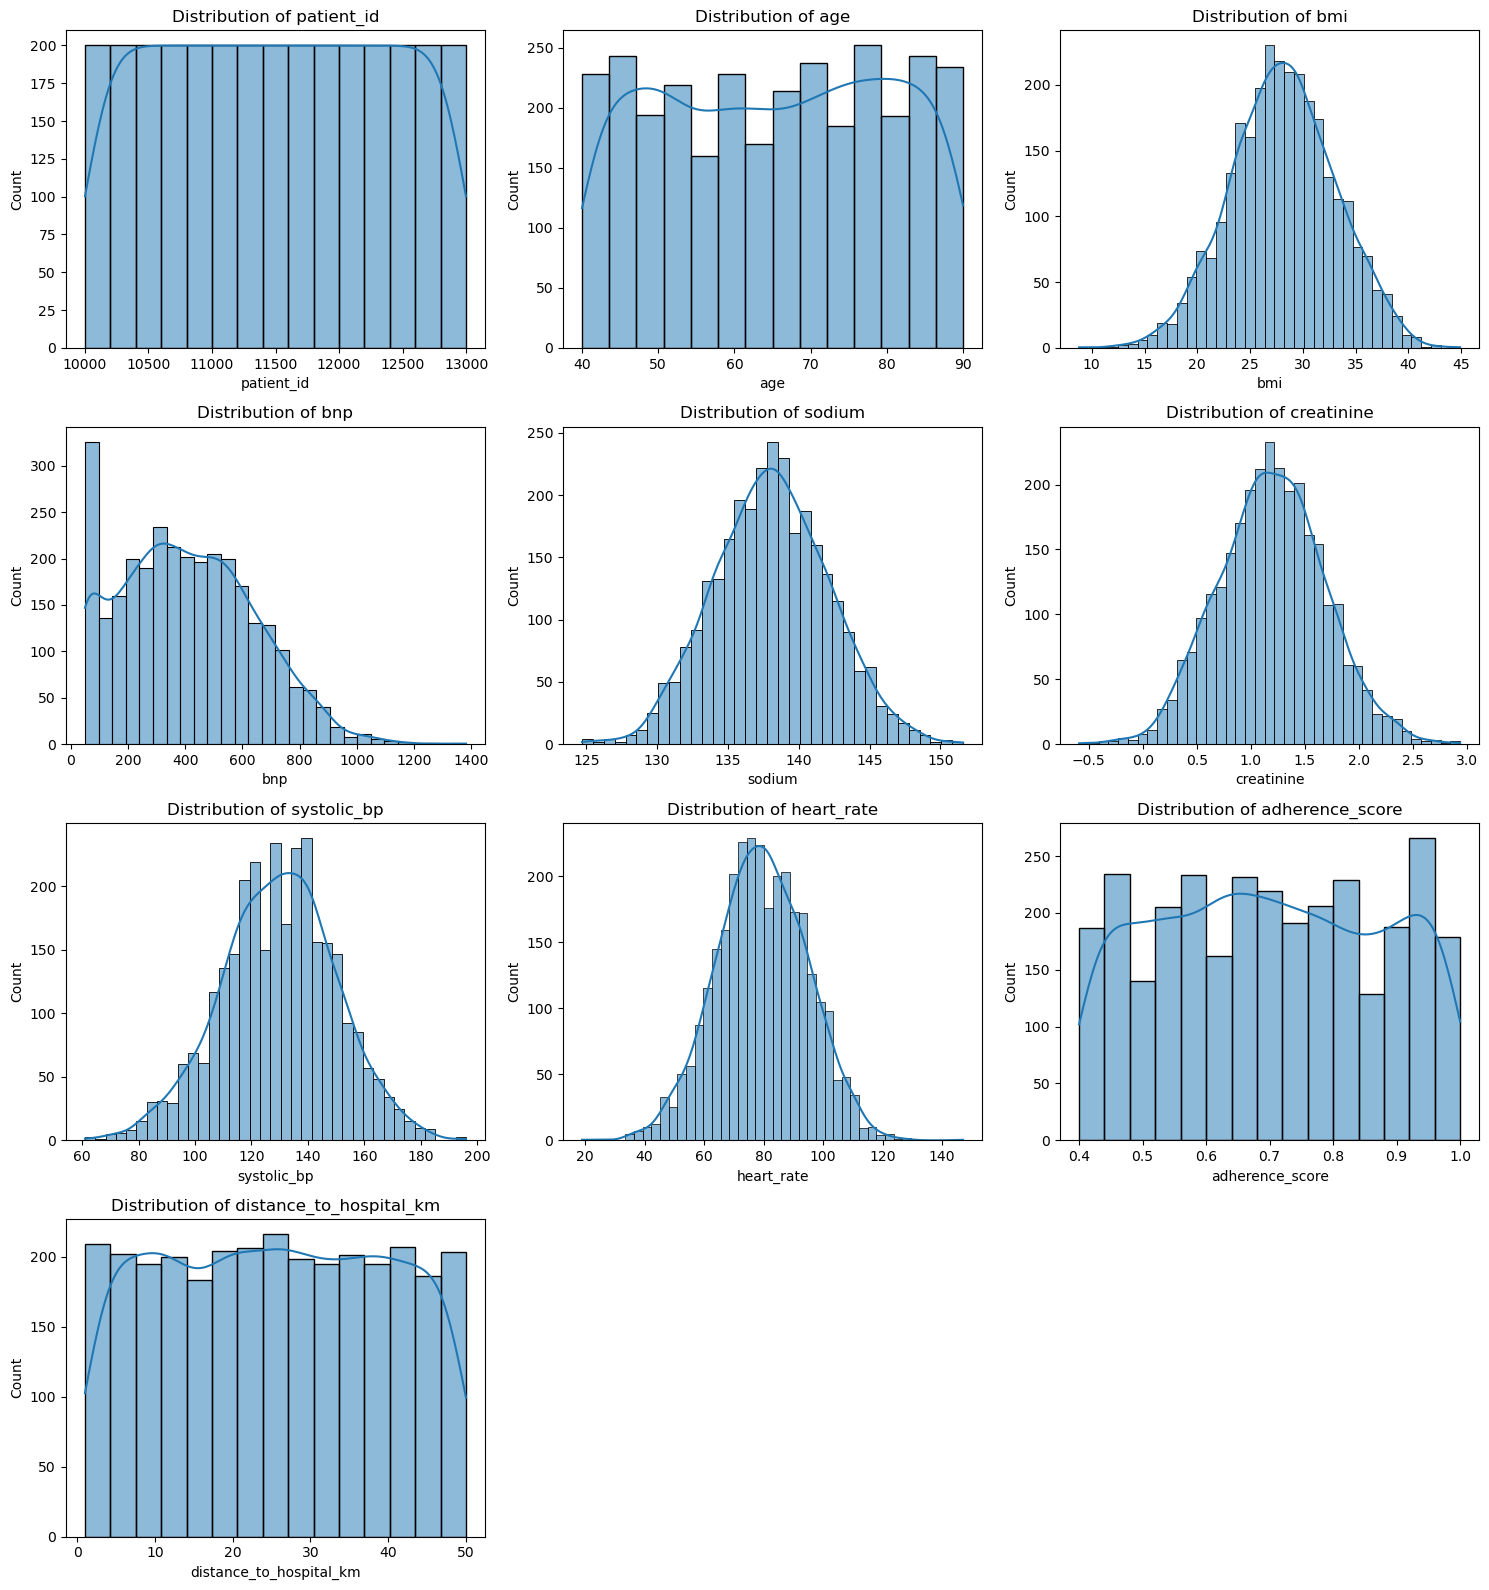


2.3 Plot Categorical Features

--- Value Counts for gender ---
gender
Male      1508
Female    1492
Name: count, dtype: int64


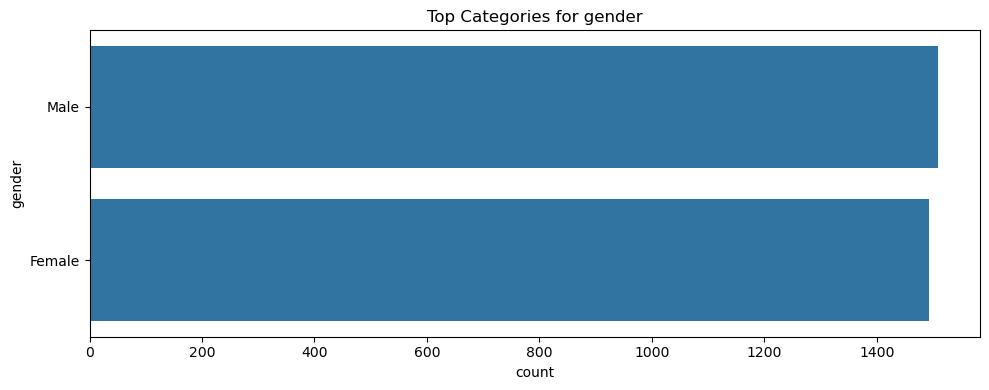

--- Value Counts for income_level ---
income_level
Low       1024
Medium     998
High       978
Name: count, dtype: int64


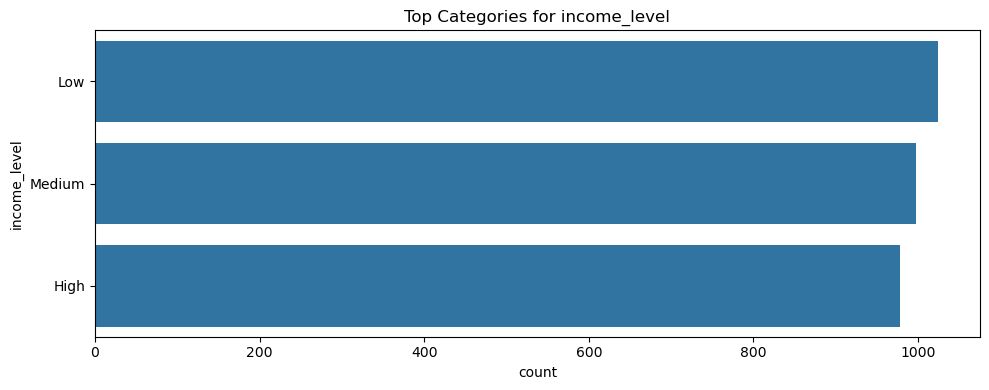

--- Value Counts for ace_inhibitor ---
ace_inhibitor
1    1565
0    1435
Name: count, dtype: int64


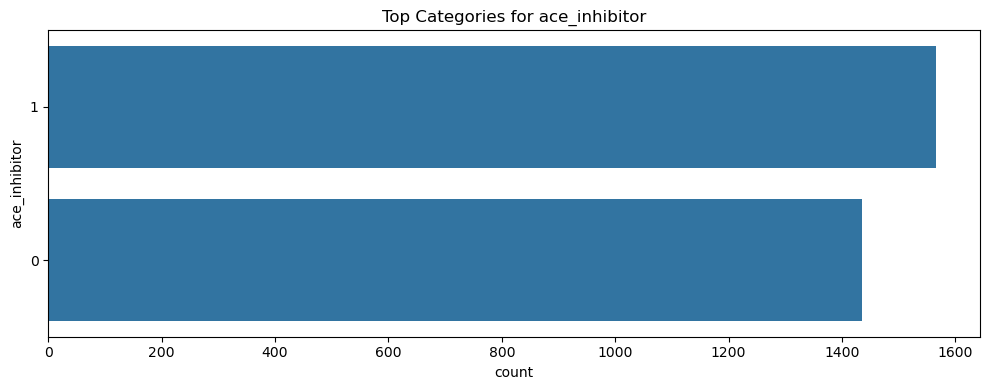

--- Value Counts for beta_blocker ---
beta_blocker
1    1510
0    1490
Name: count, dtype: int64


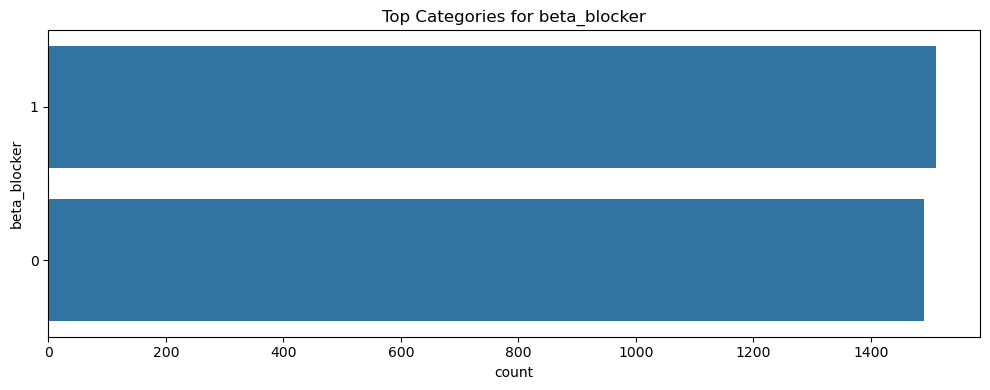

--- Value Counts for diuretic ---
diuretic
0    1533
1    1467
Name: count, dtype: int64


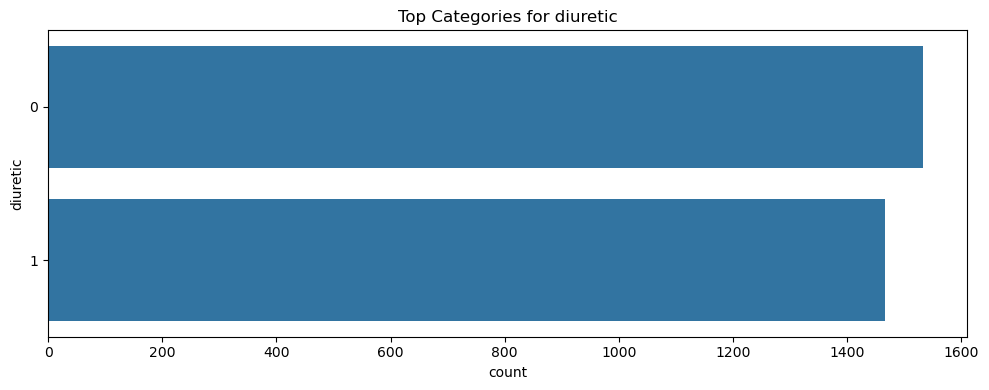

--- Value Counts for readmitted_30d ---
readmitted_30d
0    1766
1    1234
Name: count, dtype: int64


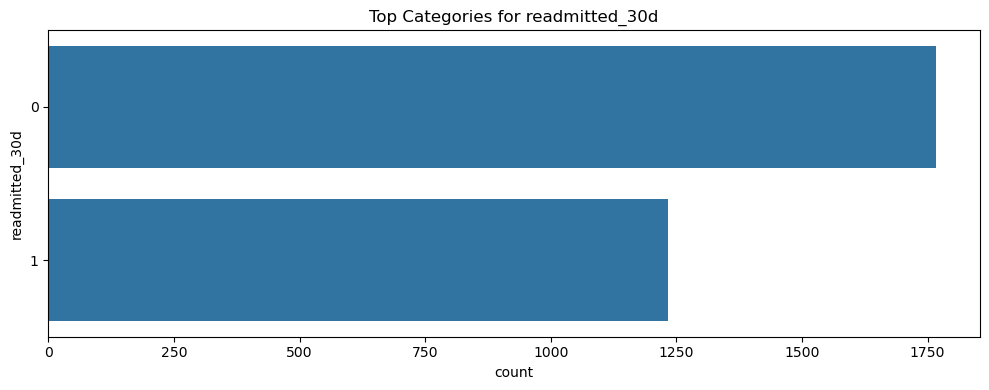

3.1 Correlation Analysis


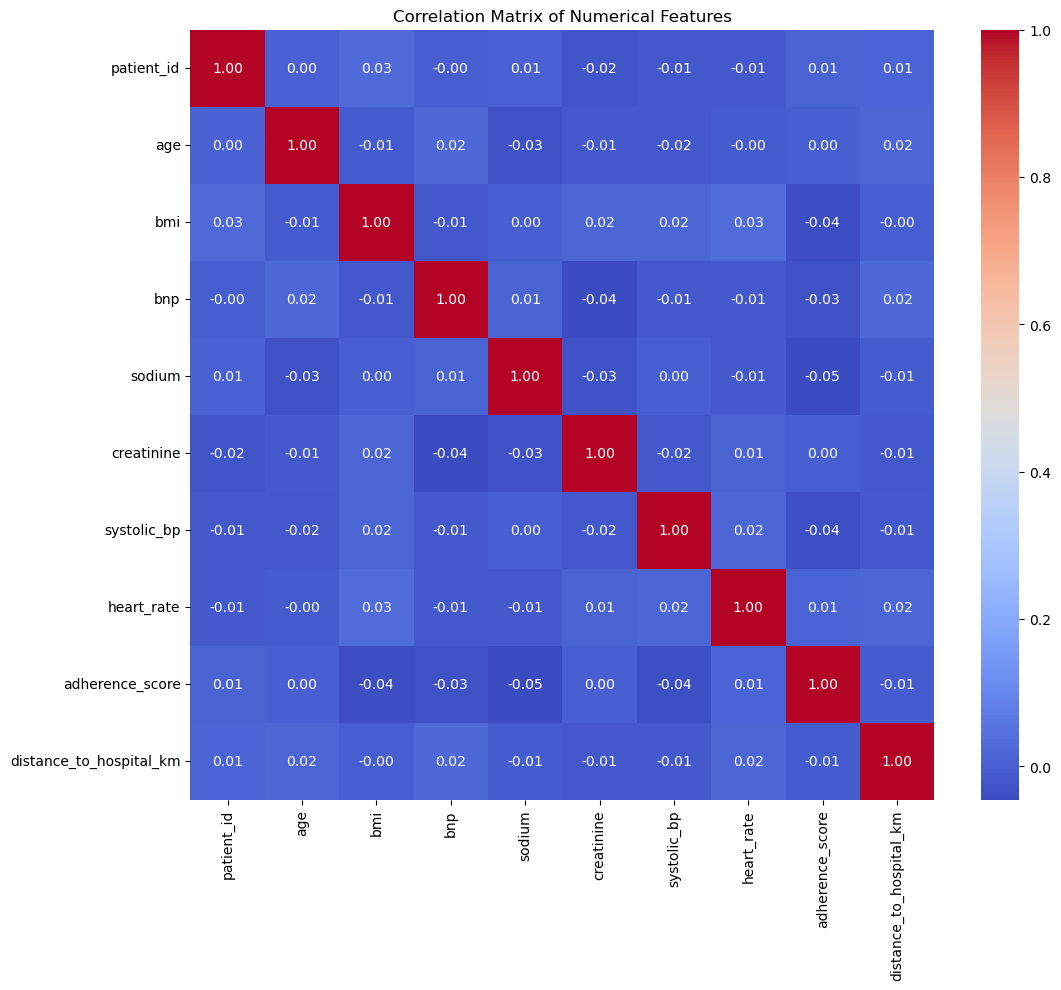


Available columns: ['patient_id', 'age', 'gender', 'bmi', 'bnp', 'sodium', 'creatinine', 'systolic_bp', 'heart_rate', 'ace_inhibitor', 'beta_blocker', 'diuretic', 'adherence_score', 'income_level', 'distance_to_hospital_km', 'readmitted_30d']

--- 3.2: Target Variable Analysis (readmitted_30d) ---

[ Class Balance ]
                Count  Percentage
readmitted_30d                   
0                1766       58.87
1                1234       41.13


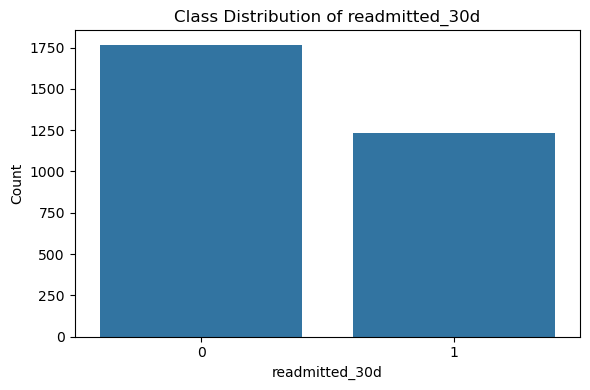


[ Numerical Features vs Target ]


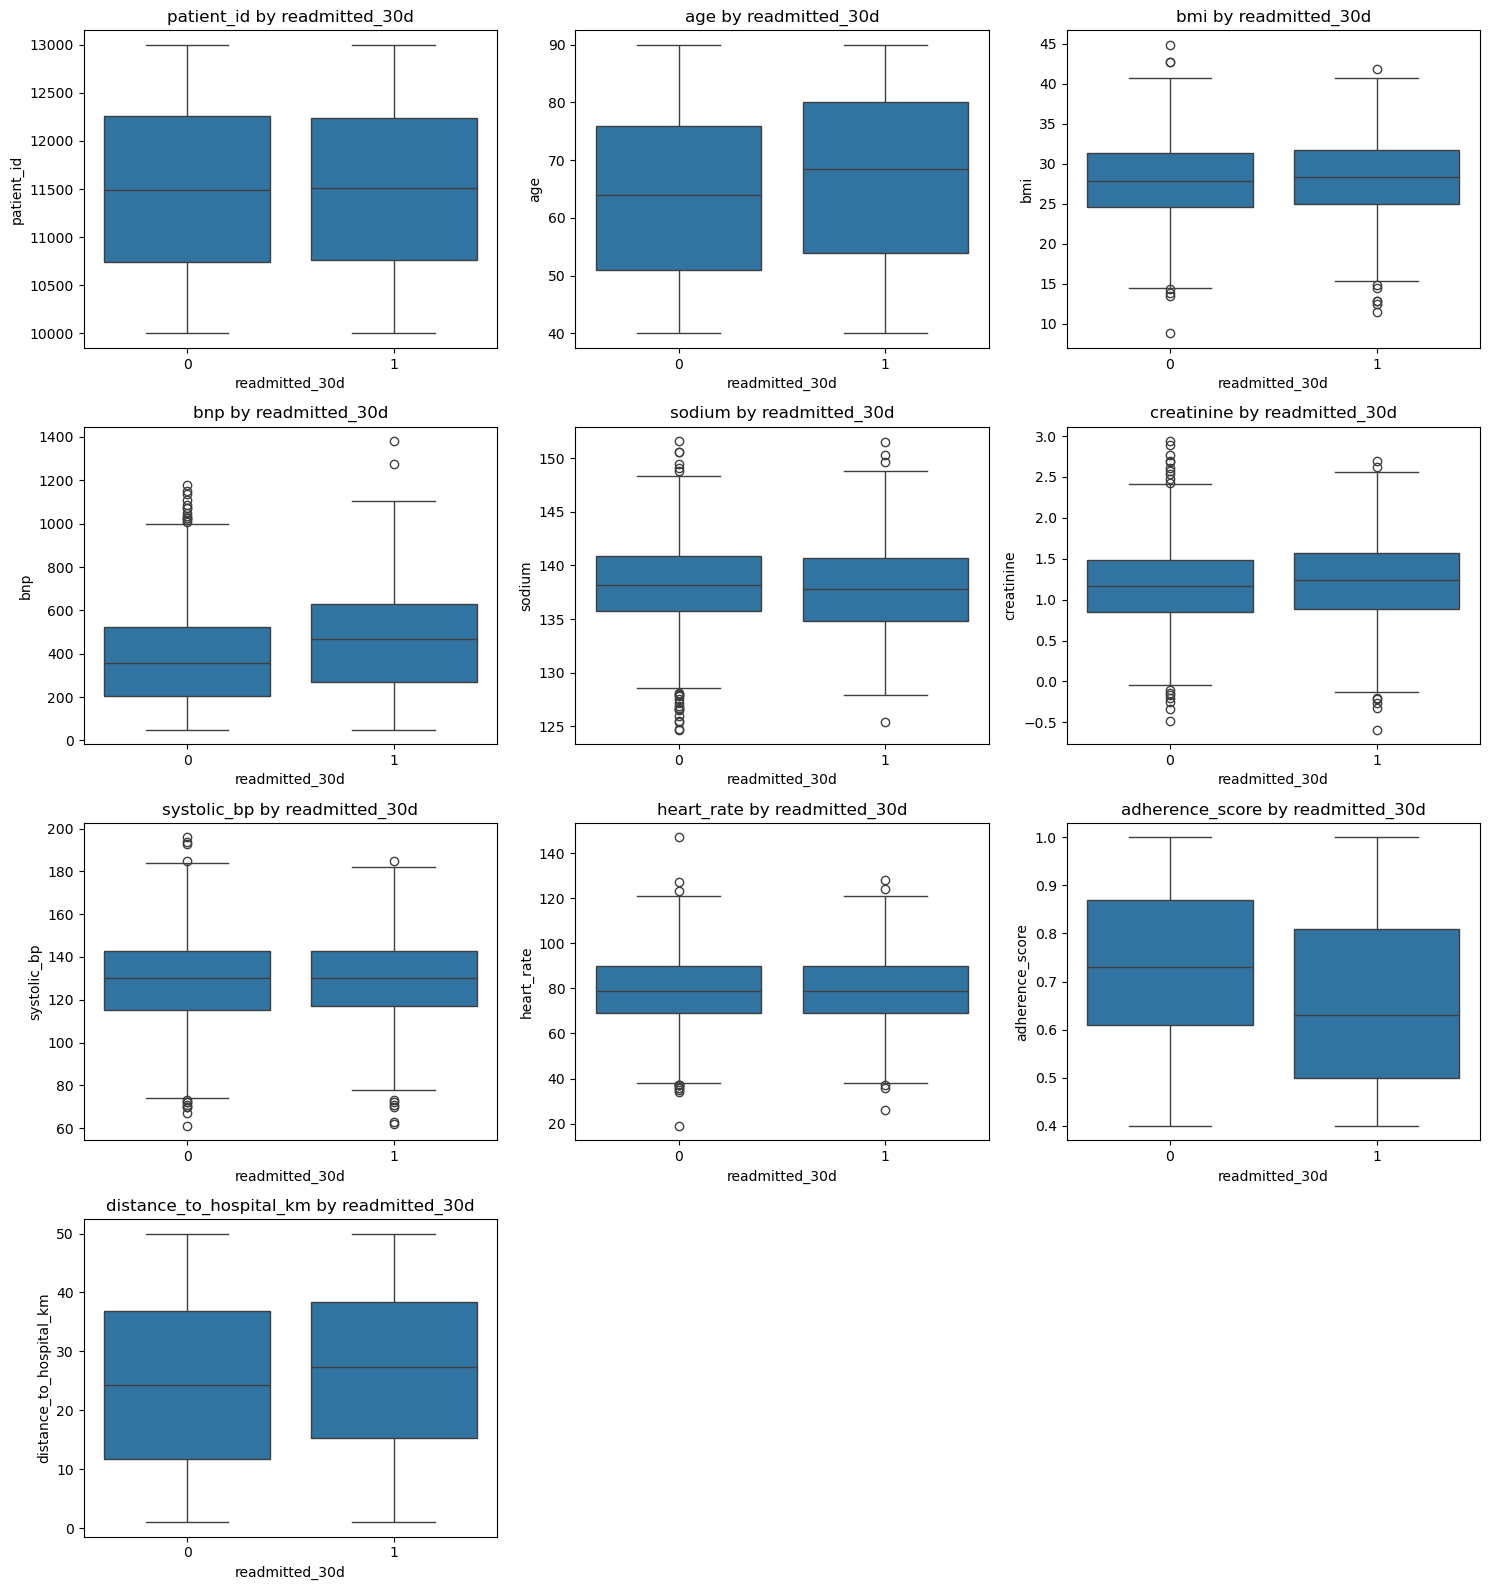

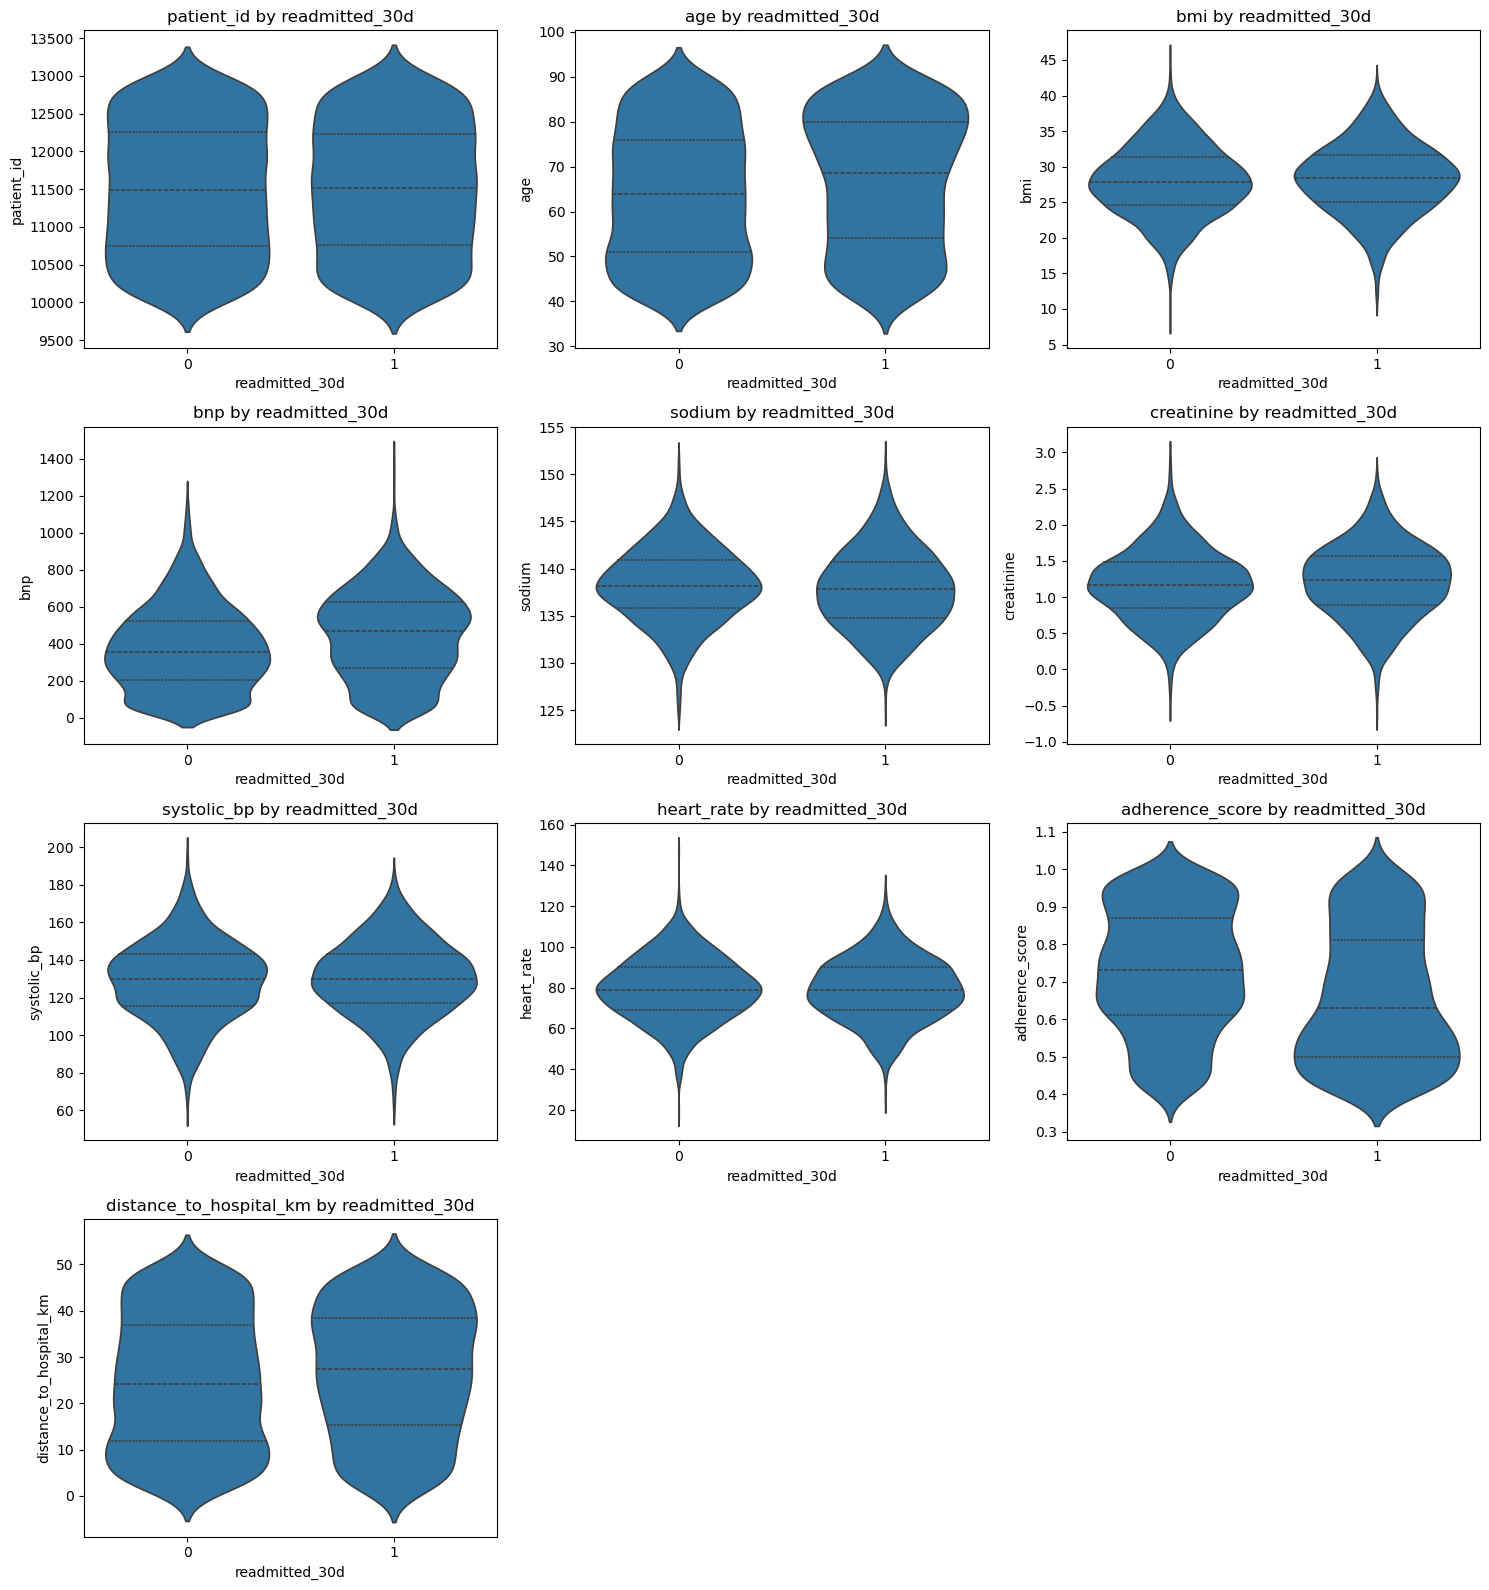


[ Mean values grouped by target ]
readmitted_30d                   0          1
patient_id               11498.240  11501.304
age                         64.122     66.875
bmi                         27.992     28.276
bnp                        374.988    451.130
sodium                     138.262    137.843
creatinine                   1.178      1.219
systolic_bp                128.995    130.438
heart_rate                  79.523     79.136
adherence_score              0.727      0.659
distance_to_hospital_km     24.607     26.534

[ Categorical Features vs Target ]


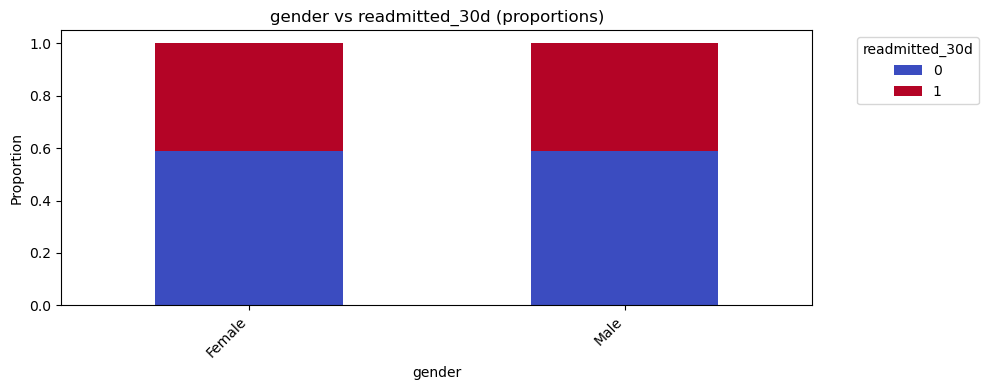

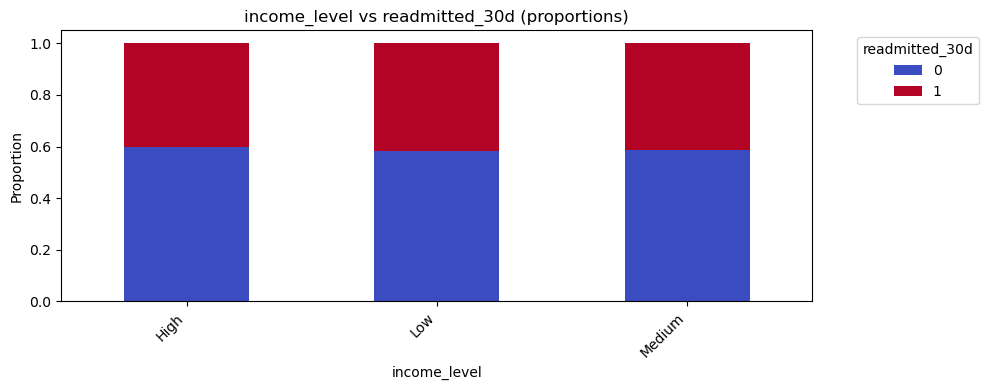

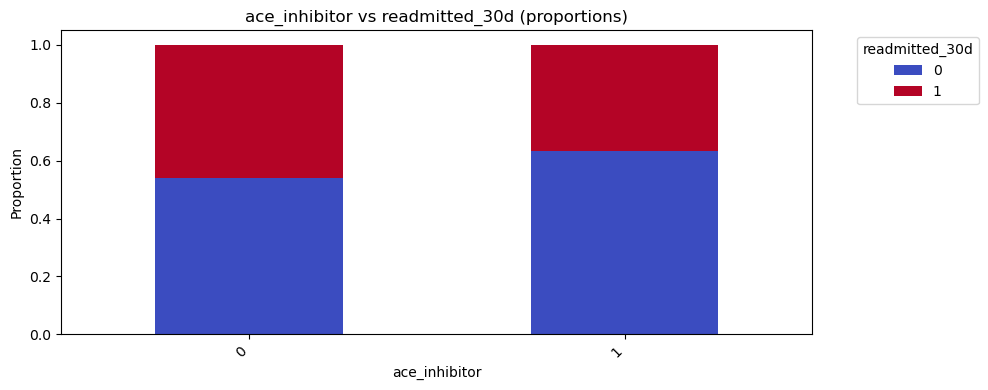

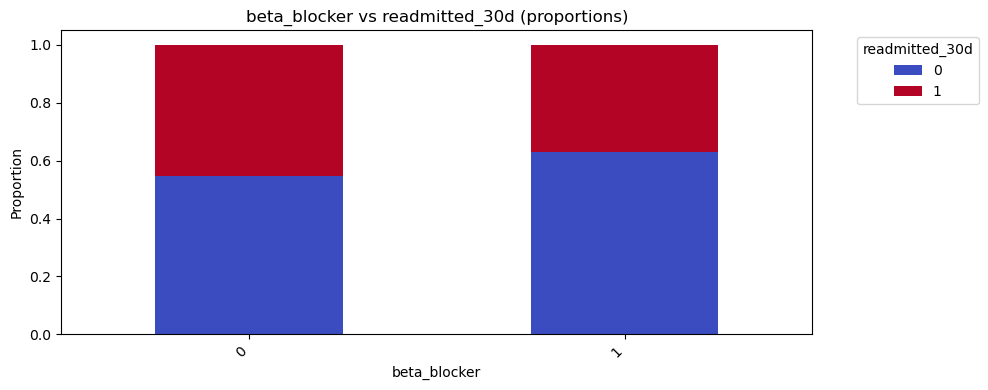

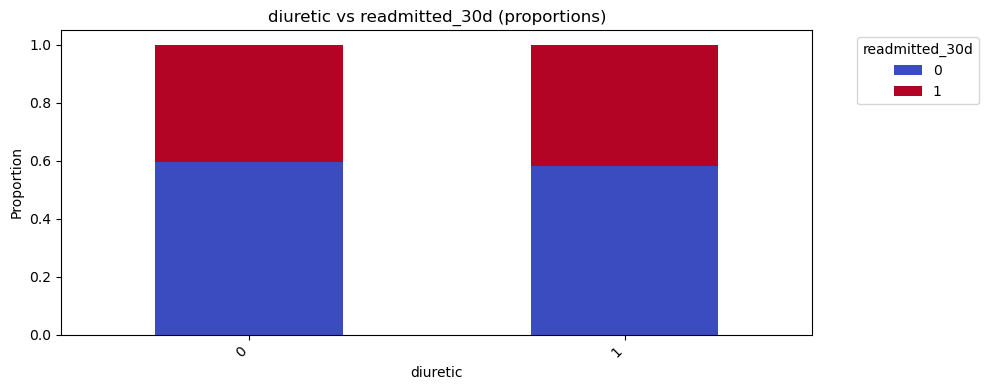


--- 4.1 Outlier Detection (IQR Method) ---
Feature 'bmi': Found 15 potential outliers.
Feature 'bnp': Found 8 potential outliers.
Feature 'sodium': Found 18 potential outliers.
Feature 'creatinine': Found 25 potential outliers.
Feature 'systolic_bp': Found 22 potential outliers.
Feature 'heart_rate': Found 17 potential outliers.
Total potential outliers identified across numerical features: 105

--- 4.2 Feature Encoding (In Planning Stages) ---
Shape after One-Hot Encoding: (3000, 17)
Note: The resulting dataset now contains binary columns for each original category.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

# Define the file path
file_path = "../data/heart_failure_readmission_dataset.csv"

# Load the dataset into a DataFrame
try:
    df = pd.read_csv(file_path)
    print("Data successfully loaded.")
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())
    print("\nDataFrame Information:")
    df.info()

except FileNotFoundError:
    print(f"Error: The file was not found at the path: {file_path}")
except Exception as e:
    print(f"An error occurred during file loading: {e}")

print(f"\n--- 1.1 Dataset Shape ---")
print(f"Shape of the dataset (Rows, Columns): {df.shape}")
print("\n")

print("--- 1.2 Data Info and Description ---")
df.info()

print("\n--- Numerical Feature Summary ---")
print(df.describe())
print("\n")
print("--- 1.3 Missing Value Analysis ---")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])
print("\n")

print(f"2.1 Split and ID Numerical/Categorical Columns")

all_numerical_cols = df.select_dtypes(include=np.number).columns

# Separate binary (0/1) indicators from true continuous features
binary_cols     = [col for col in all_numerical_cols
                   if df[col].dropna().isin([0, 1]).all() and df[col].nunique() <= 2]
numerical_cols  = [col for col in all_numerical_cols if col not in binary_cols]

# Merge string/category columns with binary indicators for categorical analysis
categorical_cols = list(df.select_dtypes(include=['str', 'category']).columns) + binary_cols

print(f"Continuous numerical columns : {numerical_cols}")
print(f"Categorical/binary columns   : {categorical_cols}")

n = len(numerical_cols)
ncols = 3
nrows = -(-n // ncols)  # ceiling division trick

print(f"\n2.2 Plot Numerical Features")

plt.figure(figsize=(15, nrows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(nrows, ncols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print(f"\n2.3 Plot Categorical Features\n")


for col in categorical_cols:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts().head(10))

    plt.figure(figsize=(10, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Show top 10 categories 
    plt.title(f'Top Categories for {col}')
    plt.tight_layout()
    plt.show()
    
print(f"3.1 Correlation Analysis")

plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# ── 3.2: Target Variable Analysis ──────────────────────────────────────────────
print("\nAvailable columns:", list(df.columns))
target_col = input("Enter the name of your target column: ").strip()

if target_col not in df.columns:
    print(f"\nColumn '{target_col}' not found in dataset. Skipping target variable analysis.")
else:
    print(f"\n--- 3.2: Target Variable Analysis ({target_col}) ---")

    # ── Class balance ──────────────────────────────────────────────────────────
    print("\n[ Class Balance ]")
    target_counts = df[target_col].value_counts()
    target_pct    = df[target_col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))

    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, order=target_counts.index)
    plt.title(f'Class Distribution of {target_col}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # ── Numerical features vs target (box plots) ───────────────────────────────
    print("\n[ Numerical Features vs Target ]")
    n_num   = len(numerical_cols)
    ncols_t = 3
    nrows_t = -(-n_num // ncols_t)  # ceiling division trick without importing math

    plt.figure(figsize=(15, nrows_t * 4))
    for i, col in enumerate(numerical_cols):
        plt.subplot(nrows_t, ncols_t, i + 1)
        sns.boxplot(x=target_col, y=col, data=df)
        plt.title(f'{col} by {target_col}')
    plt.tight_layout()
    plt.show()

    # ── Numerical features vs target (violin plots — shows distribution shape) ─
    plt.figure(figsize=(15, nrows_t * 4))
    for i, col in enumerate(numerical_cols):
        plt.subplot(nrows_t, ncols_t, i + 1)
        sns.violinplot(x=target_col, y=col, data=df, inner='quartile')
        plt.title(f'{col} by {target_col}')
    plt.tight_layout()
    plt.show()

    # ── Mean of each numerical feature grouped by target ──────────────────────
    print("\n[ Mean values grouped by target ]")
    print(df.groupby(target_col)[numerical_cols].mean().T.round(3))

    # ── Categorical features vs target (stacked proportion bar charts) ─────────
    if len(categorical_cols) > 0:
        print("\n[ Categorical Features vs Target ]")
        for col in categorical_cols:
            if col == target_col:
                continue
            top_cats = df[col].value_counts().index[:10]  # Limit to top 10 categories (lower cardinality only)
            subset   = df[df[col].isin(top_cats)]

            prop_df = (
                subset.groupby([col, target_col])
                      .size()
                      .unstack(fill_value=0)
                      .apply(lambda r: r / r.sum(), axis=1)  # Normalize to proportions
            )

            prop_df.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='coolwarm')
            plt.title(f'{col} vs {target_col} (proportions)')
            plt.ylabel('Proportion')
            plt.xlabel(col)
            plt.xticks(rotation=45, ha='right')
            plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

print("\n--- 4.1 Outlier Detection (IQR Method) ---")

outlier_count = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        print(f"Feature '{col}': Found {len(outliers)} potential outliers.")
        outlier_count += len(outliers)
        # Decision Point: You must decide: remove, cap (winsorize), or transform.
        # Example Action (Capping):
        # df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print(f"Total potential outliers identified across numerical features: {outlier_count}")

print("\n--- 4.2 Feature Encoding (In Planning Stages) ---")
# Strategy 1: Low Cardinality (e.g., < 15 unique values) -> One-Hot Encoding (OHE)
# Strategy 2: High Cardinality -> Target Encoding or Frequency Encoding (to prevent OHE explosion)

cols_to_encode = [col for col in categorical_cols if col != target_col]
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)  # drop_first avoids multicollinearity
print(f"Shape after One-Hot Encoding: {df_encoded.shape}")  
print("Note: The resulting dataset now contains binary columns for each original category.")
# Note: this fxn could save to a .csv, or this could be passed on for further analysis in later stepd TBD
